In [1]:
from datetime import date
from pathlib import Path

from tapas_gmm.env.rlbench import RLBenchEnvironment, RLBenchEnvironmentConfig
from tapas_gmm.policy.gmm import GMMPolicy, GMMPolicyConfig
from tapas_gmm.policy.models.tpgmm import AutoTPGMMConfig
from tapas_gmm.viz.gmm import plot_gmm_components

from rlbench.action_modes.arm_action_modes import BimanualEndEffectorPoseViaIK

import imageio.v2 as imageio
import matplotlib.pyplot as plt

2026-08-03 15:31:37.865 | INFO     |  Running on cpu


/home/nils/Documents/Study Project/Code/riepybdlib/riepybdlib/data.py:34: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_listdir


In [2]:
checkpoint_root = Path("../artifacts/checkpoints/tapas")
checkpoint_dir = max(path for path in checkpoint_root.iterdir() if path.is_dir())
model_path = checkpoint_dir / "latest.pkl"
video_dir = Path("../artifacts/videos/tapas") / date.today().isoformat()
video_dir.mkdir(parents=True, exist_ok=True)

In [3]:
tapas_env = RLBenchEnvironment(
    RLBenchEnvironmentConfig(
        action_mode = BimanualEndEffectorPoseViaIK,
        robot_setup = "dual_panda",
        task = "BimanualDualPushButtons",
        cameras = ("front",),
        camera_pose = {},
        image_size = (128, 128),
        static = False,
        headless = False,
        scale_action = False,
        delay_gripper = False,
        gripper_plot = False,   
    )
)

policy = GMMPolicy(
    GMMPolicyConfig(
        suffix=None,
        model = AutoTPGMMConfig(),
        batch_predict_in_t_models = True,
        topp_in_t_models = False,
        dbg_prediction = True,
        binary_gripper_action = True,
        force_overwrite_checkpoint_config = True,
        pos_lag_thresh=0.03,
        quat_change_thresh=0.1,
    )
)

2026-08-03 15:31:45.105 | INFO     |  Initializing Policy:
2026-08-03 15:31:45.105 | INFO     |  No encoder config provided. Using None.
None


In [4]:
obs = tapas_env.reset()
policy.from_disk(str(model_path))
policy.eval()
policy.reset_episode(tapas_env)

2026-08-03 15:31:46.560 | INFO     |  Loading model:
2026-08-03 15:31:46.646 | ERROR    |  Config mismatch
root.tpgmm.reg_diag  0.0002 != 0.001
root.tpgmm.add_time_component True != False
root.tpgmm.add_action_component False != True
root.tpgmm.reg_diag_gripper 0.02 != 0.1
root.tpgmm.reg_init_diag 0.0005 != 5e-05
root.tpgmm.reg_em_finish_diag 0.0002 != 0.001
root.tpgmm.add_gripper_action True != False
root.tpgmm.reg_em_trans 1e-06 != None
root.tpgmm.n_components 10 != 4
root.tpgmm.reg_em_finish_diag_gripper 0.02 != 0.1
root.frame_selection.rel_score_threshold 0.1 != 0.75
root.demos_segmentation.velocity_based True != False
root.demos_segmentation.components_prop_to_len True != False
root.demos_segmentation.min_n_components 3 != 1
root.demos_segmentation.distance_based False != True

2026-08-03 15:31:46.646 | WARNING  |  Overwriting config. This can lead to unexpected errors.
2026-08-03 15:31:46.646 | INFO     |  Detected time-based model: True. Using time-driven policy. Set time_based 

2026-08-03 15:31:46.666 | WARNING  |  Implementation lacking modulo rots, enforce z-up/down, etc.
2026-08-03 15:31:47.225 | INFO     |  Predicted 41 steps in batch.


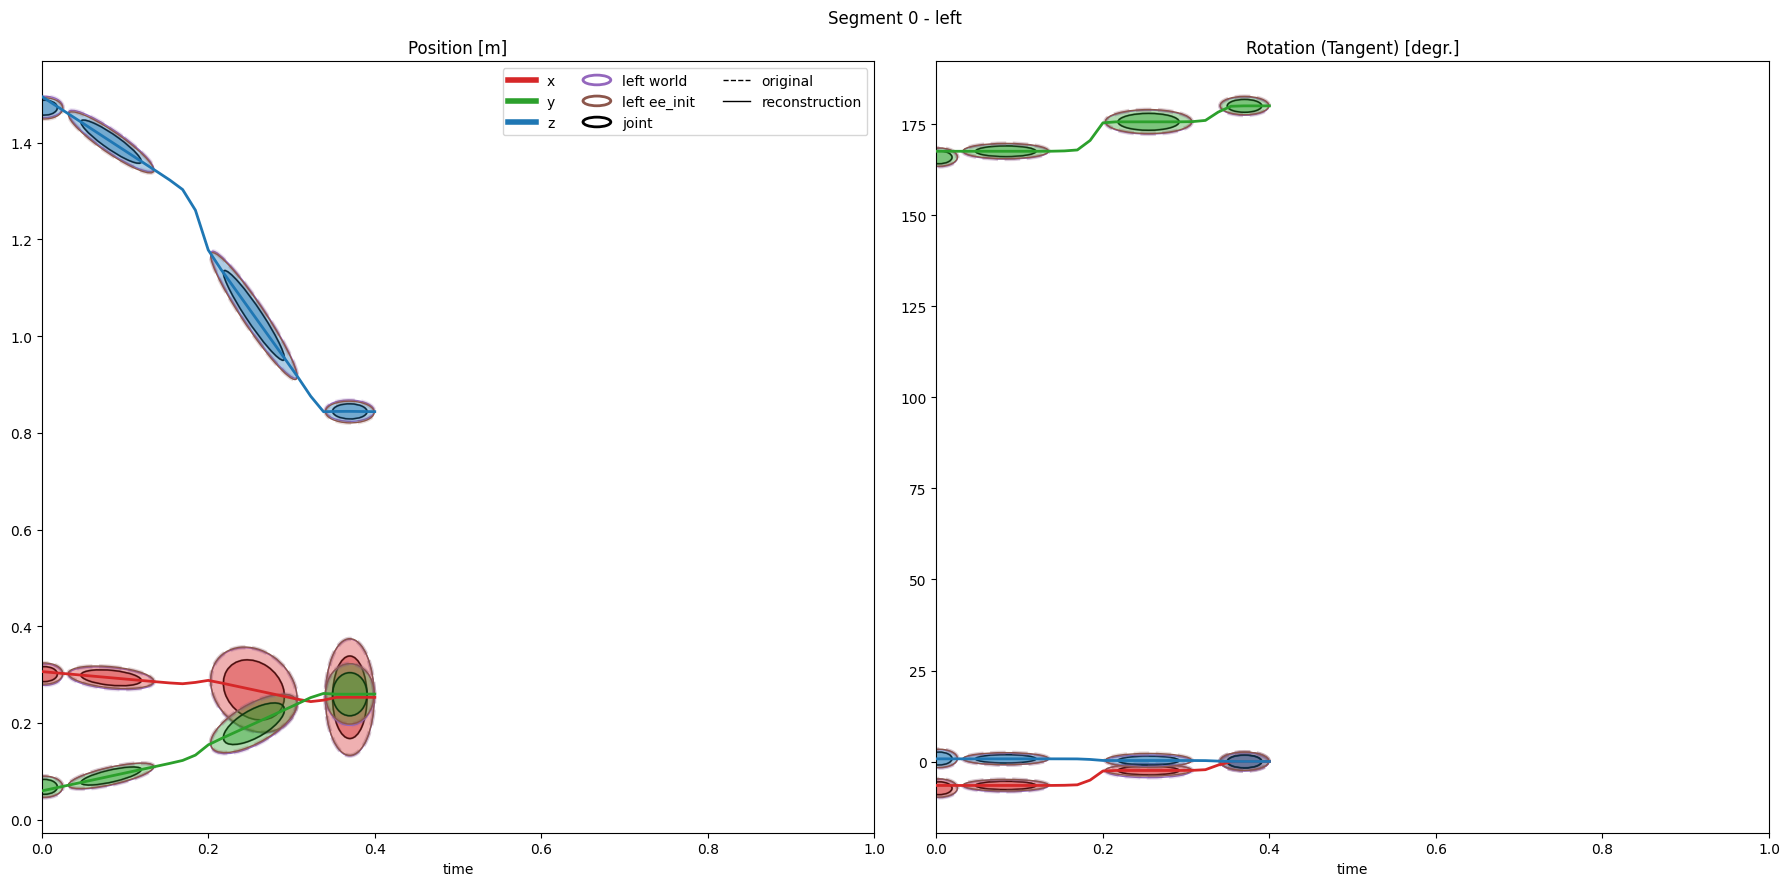

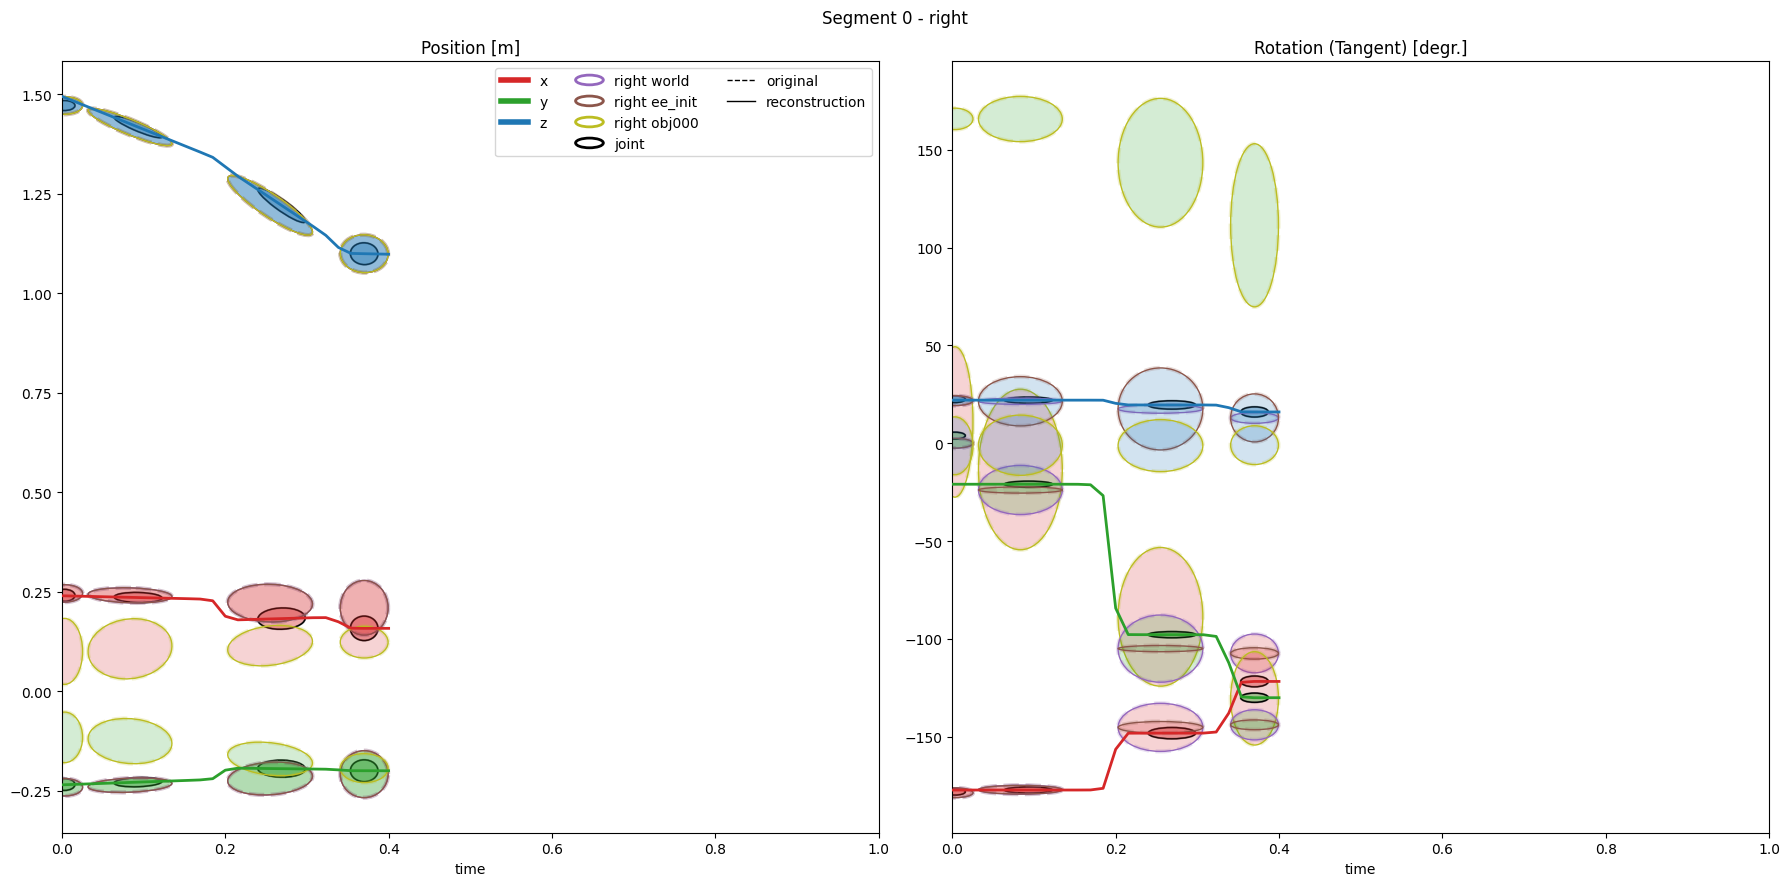

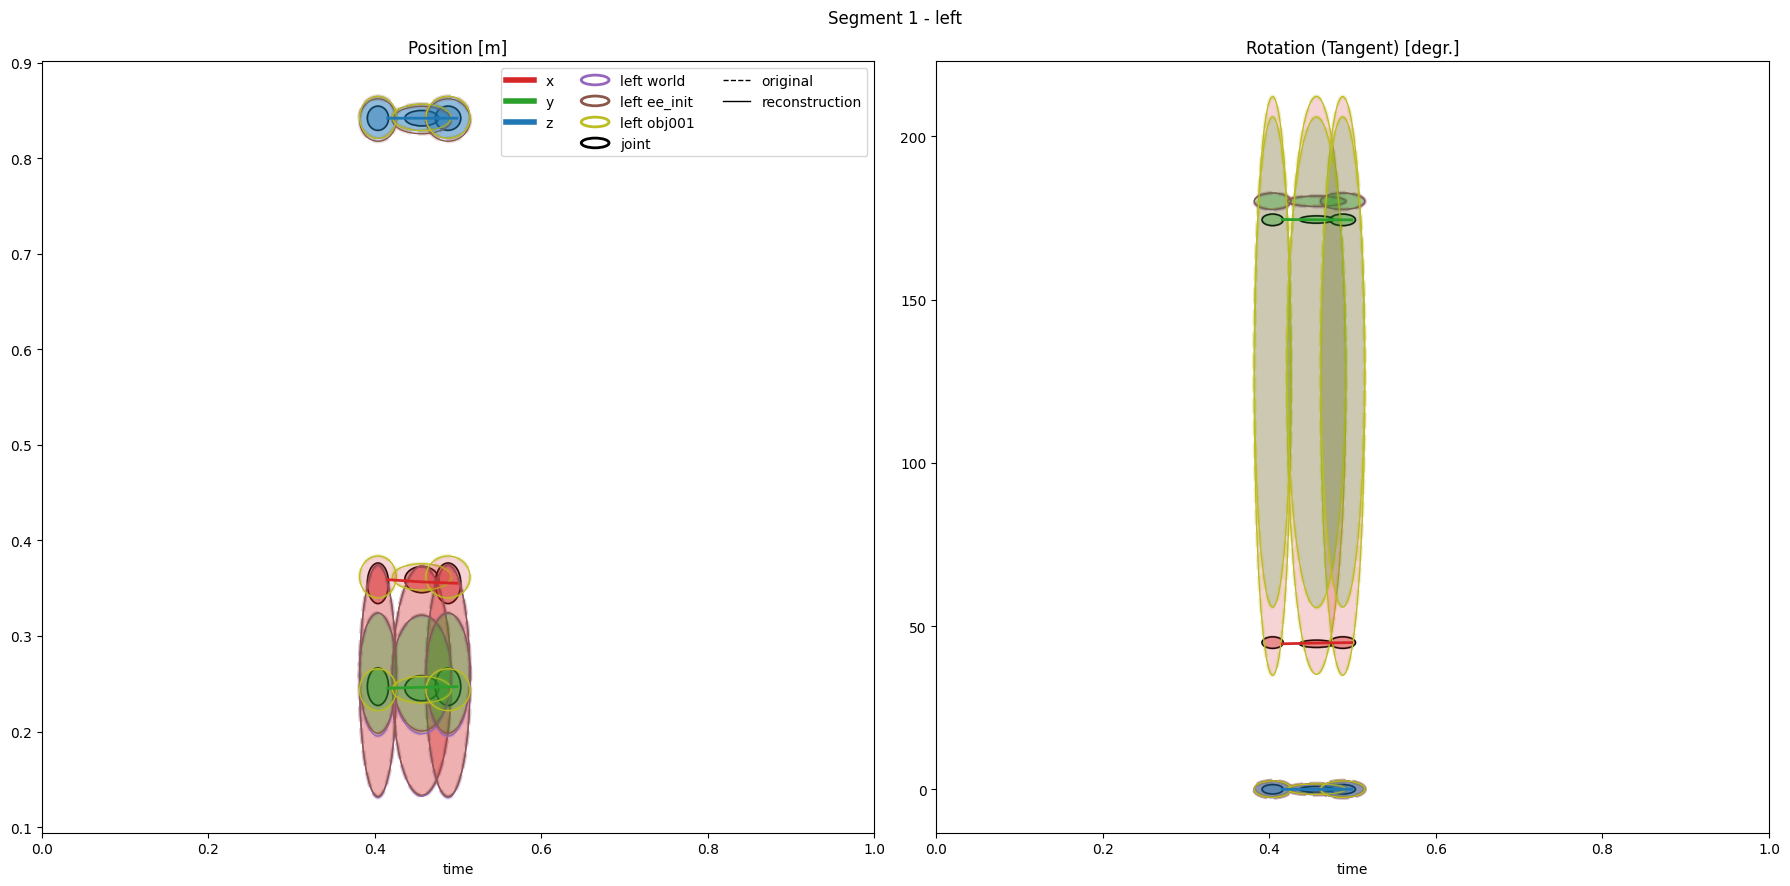

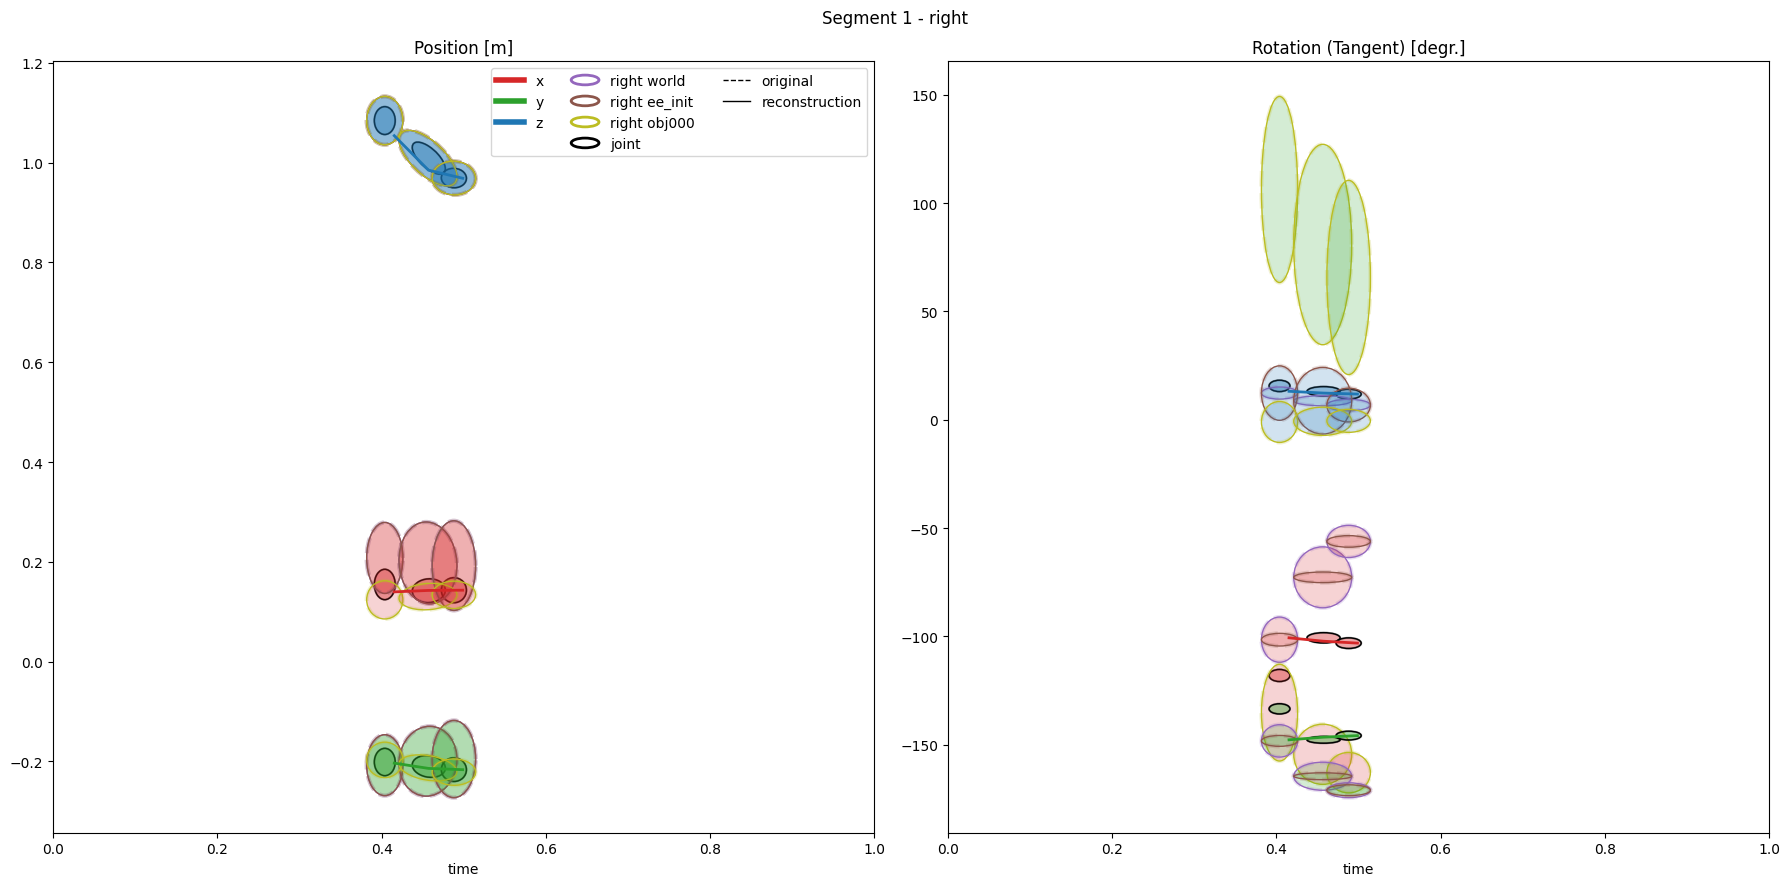

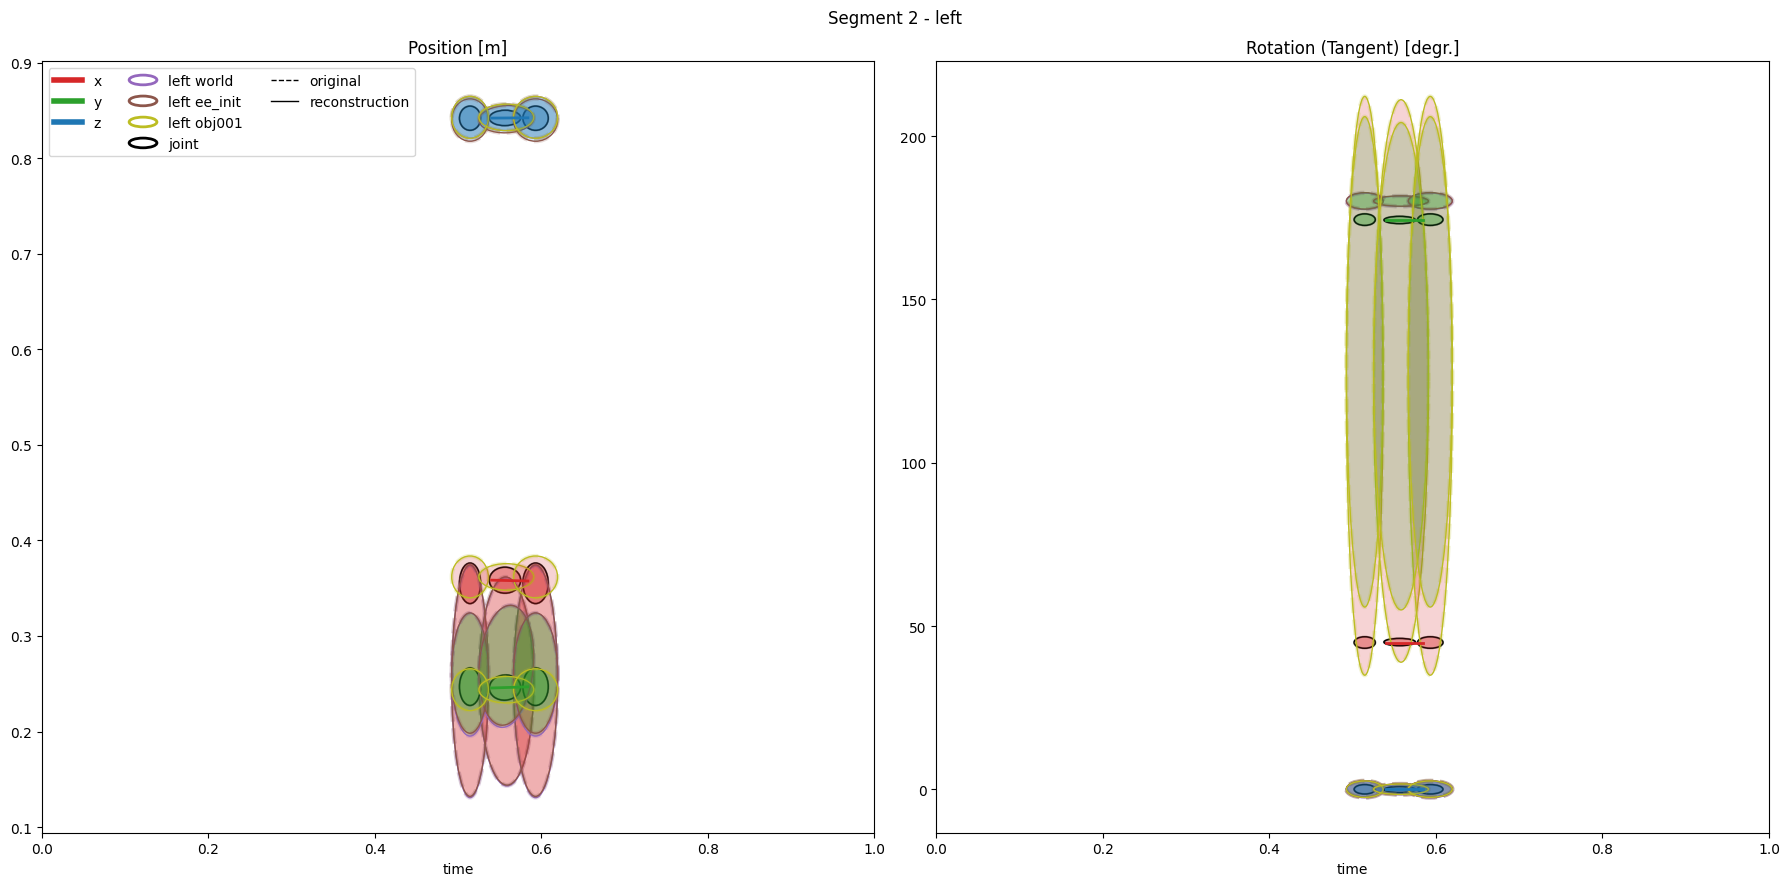

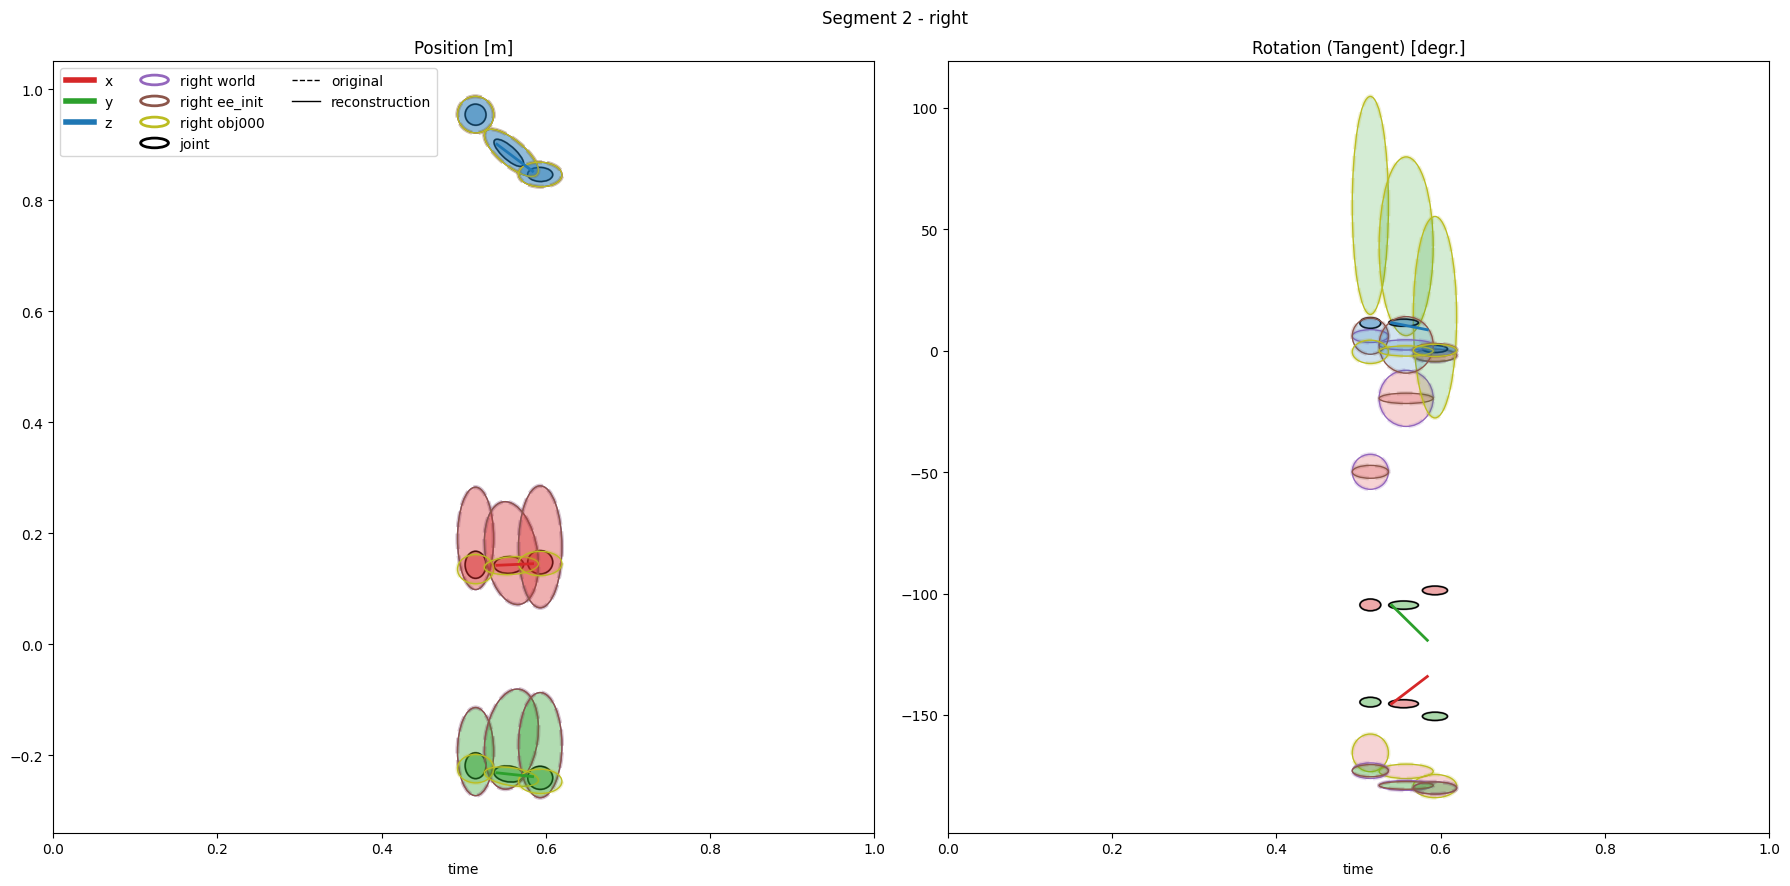

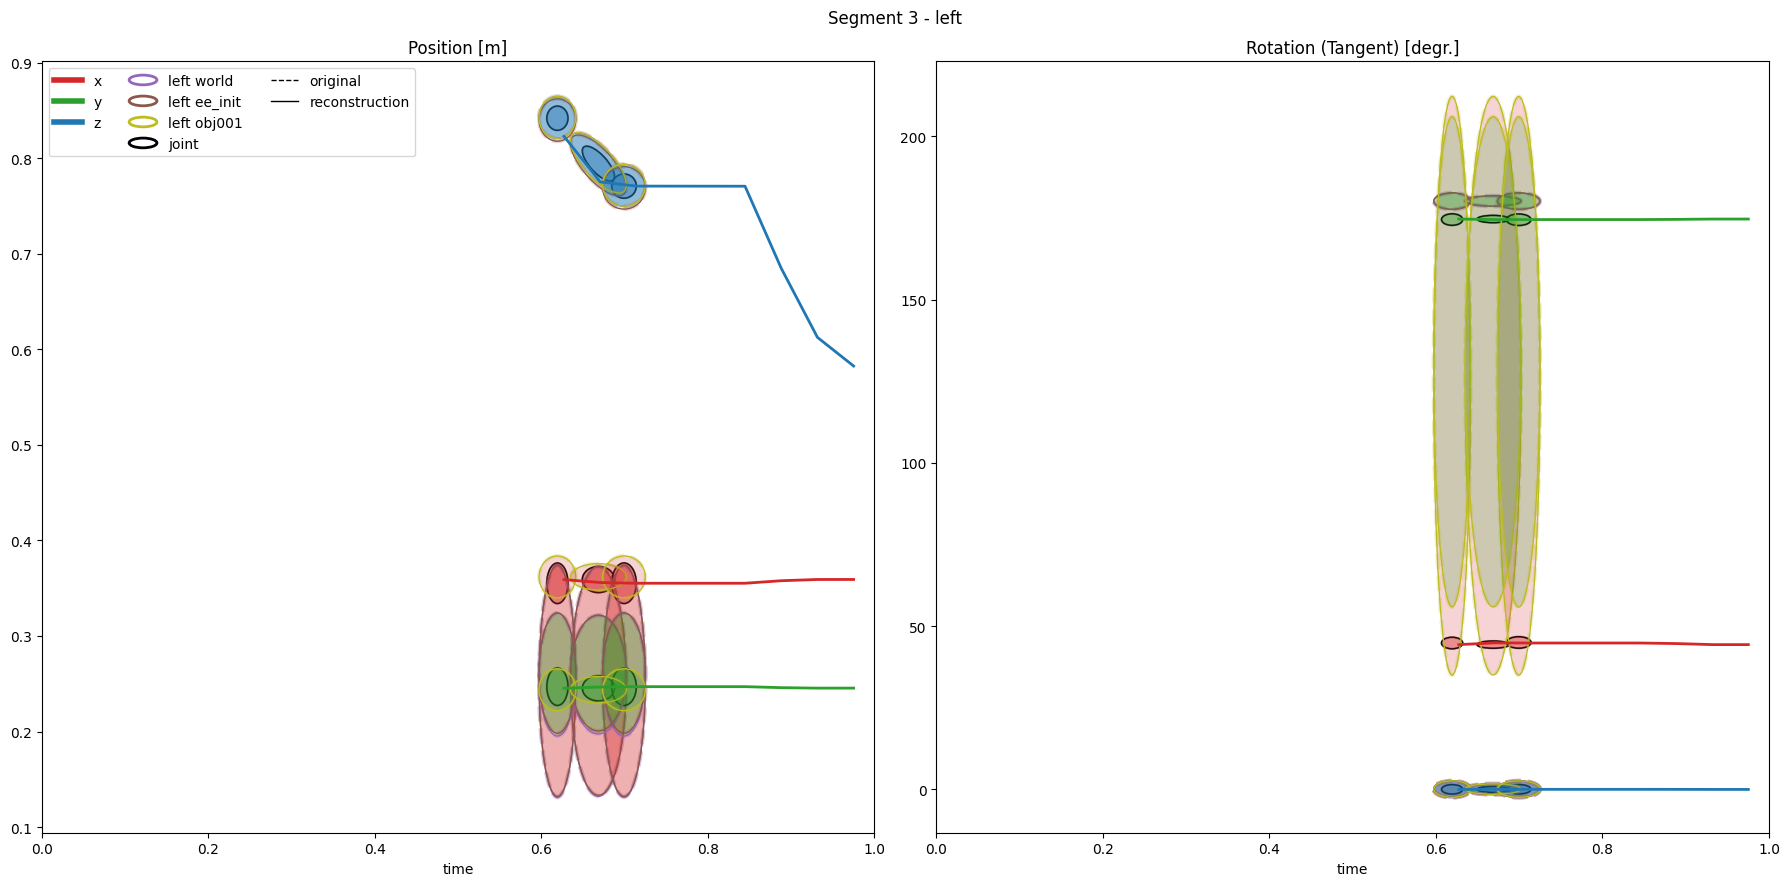

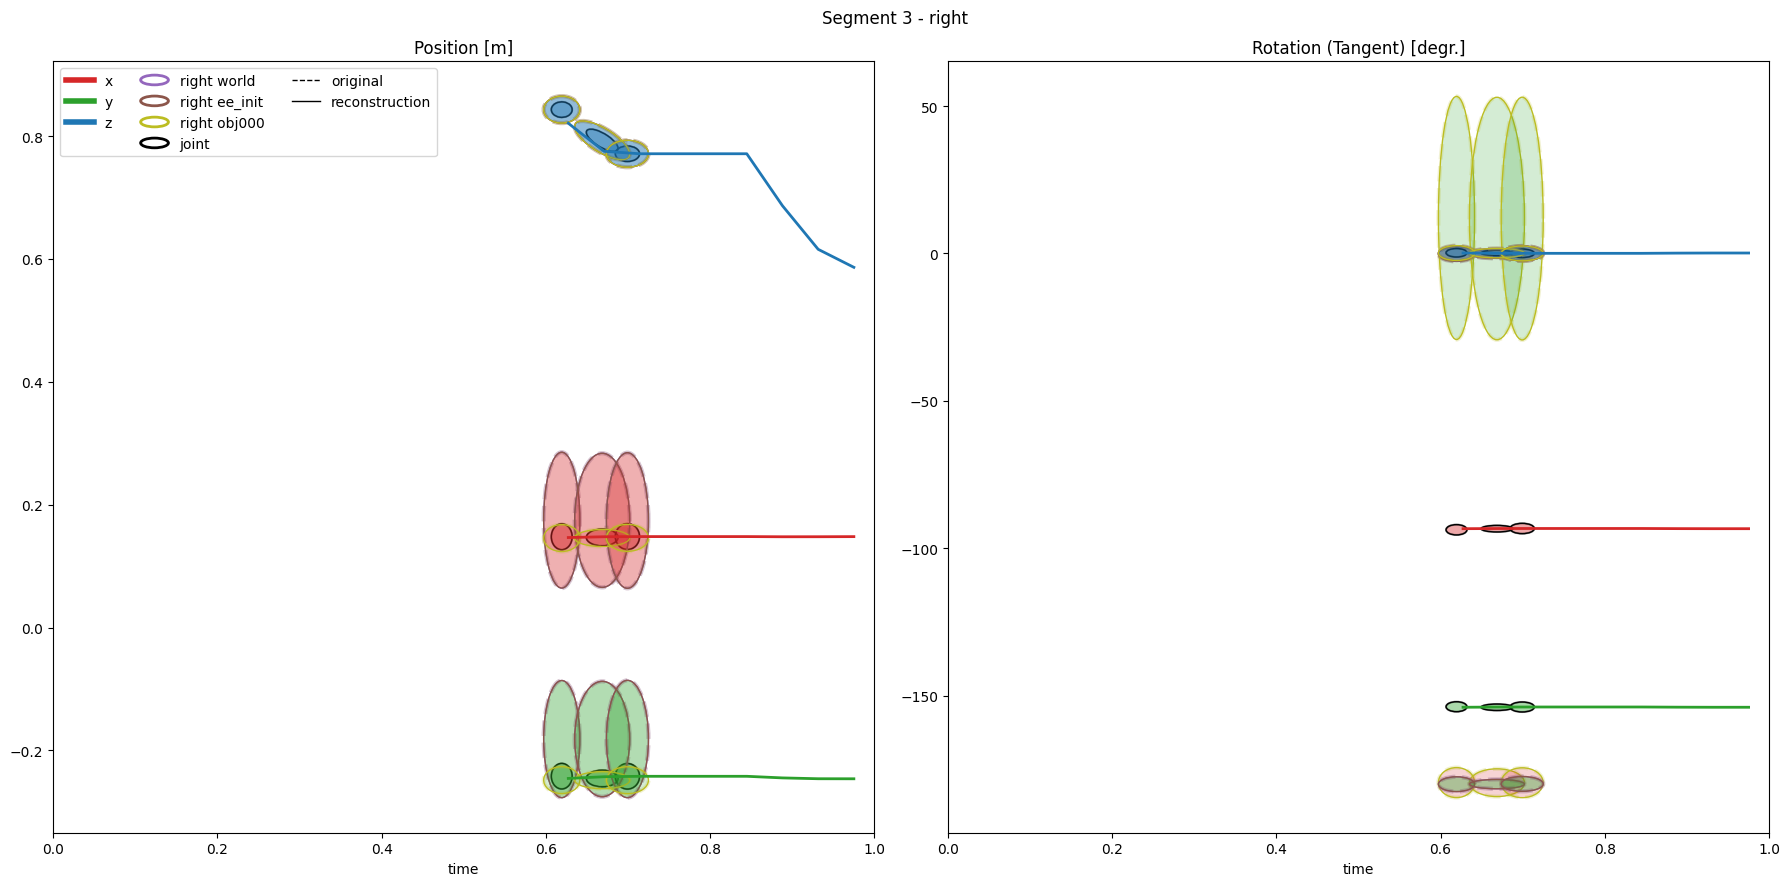

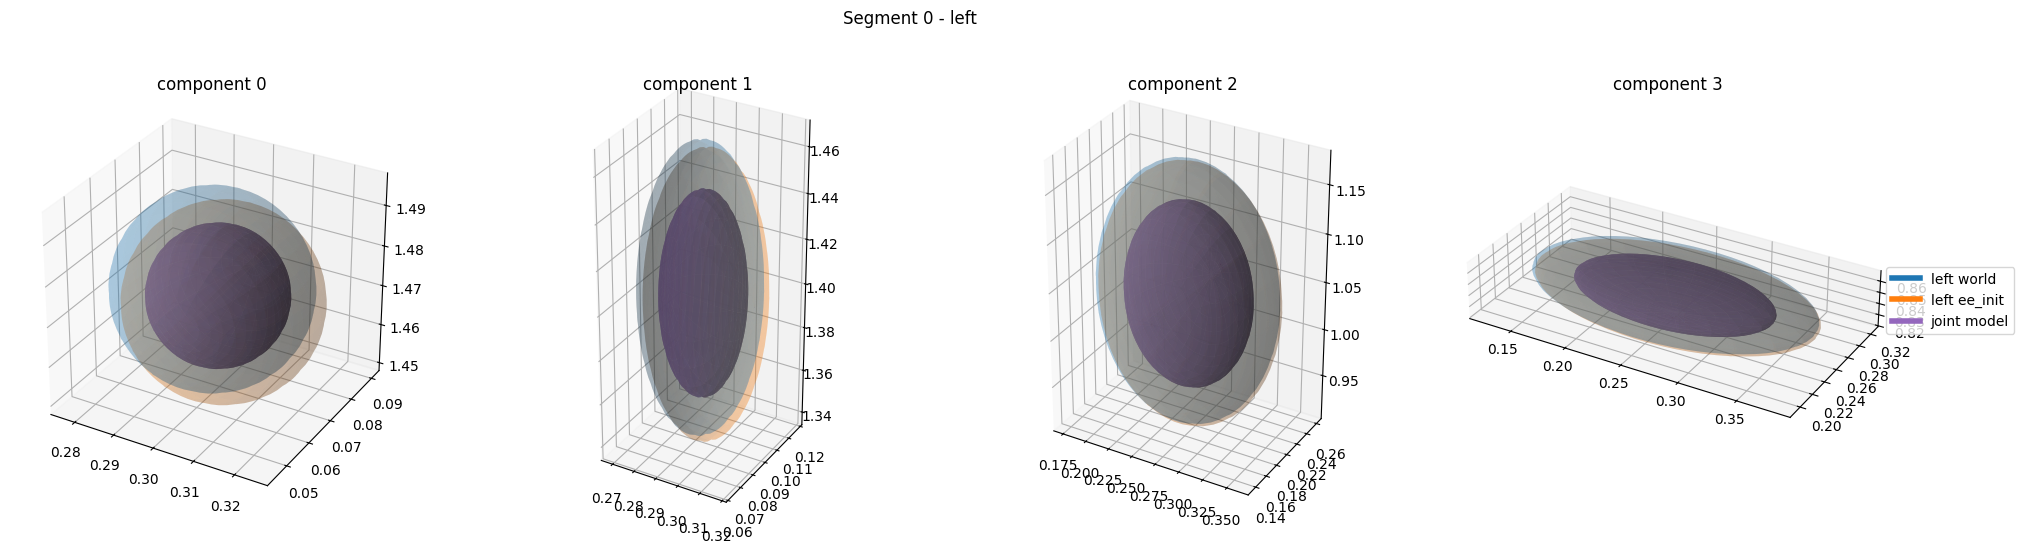

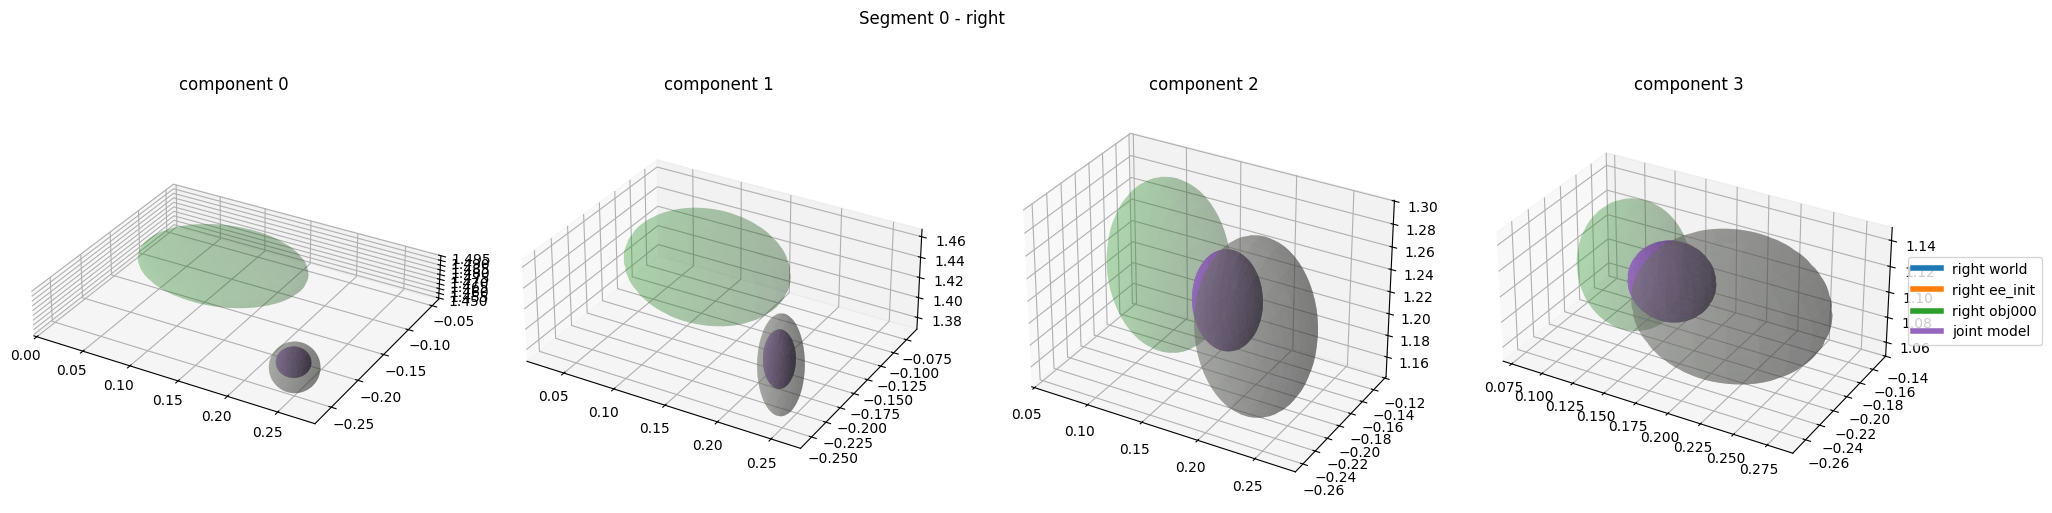

2026-08-03 15:31:58.953 | INFO     |  Action [-1.13484068e-02 -6.12226794e-03 -2.05983125e-02 -1.30794201e-02
 -2.29195477e-03 -1.15847676e-01  9.93178228e-01  1.00000000e+00
  0.00000000e+00 -9.12647742e-03 -9.10779990e-03 -2.29084203e-02
  7.88491864e-04  1.36719431e-02  4.39271647e-03  9.99896575e-01
  1.00000000e+00  0.00000000e+00]
2026-08-03 15:31:58.959 | INFO     |  Skipping invalid action [-1.13484068e-02 -6.12226794e-03 -2.05983125e-02 -1.30794201e-02
 -2.29195477e-03 -1.15847676e-01  9.93178228e-01  1.00000000e+00
  0.00000000e+00 -9.12647742e-03 -9.10779990e-03 -2.29084203e-02
  7.88491864e-04  1.36719431e-02  4.39271647e-03  9.99896575e-01
  1.00000000e+00  0.00000000e+00].


2026-08-03 15:32:00.080 | INFO     |  Action [-8.91133726e-03 -7.23568481e-03 -8.45506355e-03 -1.30305079e-02
 -2.66188775e-03 -1.15856069e-01  9.93176969e-01  1.00000000e+00
  0.00000000e+00 -3.09564679e-03 -3.23373288e-03 -6.95392535e-03
  7.81862685e-04  1.32933861e-02  4.38992643e-03  9.99901697e-01
  1.00000000e+00  0.00000000e+00]
2026-08-03 15:32:00.087 | INFO     |  Skipping invalid action [-8.91133726e-03 -7.23568481e-03 -8.45506355e-03 -1.30305079e-02
 -2.66188775e-03 -1.15856069e-01  9.93176969e-01  1.00000000e+00
  0.00000000e+00 -3.09564679e-03 -3.23373288e-03 -6.95392535e-03
  7.81862685e-04  1.32933861e-02  4.38992643e-03  9.99901697e-01
  1.00000000e+00  0.00000000e+00].
2026-08-03 15:32:00.179 | INFO     |  Action [-6.49841254e-03 -8.34131393e-03  3.62610886e-03 -1.29773175e-02
 -3.13147613e-03 -1.15865752e-01  9.93175166e-01  1.00000000e+00
  0.00000000e+00  2.88846453e-03  2.65131537e-03  8.99576346e-03
  7.70325990e-04  1.28730497e-02  4.37630699e-03  9.99907265e-01

In [5]:
total_reward = 0
frames = []

for step in range(450):
    segment = policy.model._online_active_segment
    new_segment = policy.model._online_first_step
    action, info = policy.predict(obs)

    if policy.config.dbg_prediction and new_segment:
        segment_gmm = policy.model.segment_gmms[segment]
        frame_data = policy.model.segment_frame_views[segment]
        n_left = len(frame_data.left_frame_indecies or [])
        joint_models = policy.model._online_joint_models[segment]
        trans_marginals = policy.model._online_trans_margs_joint[segment]

        plot_gmm_components(
            segment_gmm.model,
            (joint_models[0],),
            (trans_marginals[0],),
            frame_data.frame_names[:n_left],
            time_based=policy._time_based,
        )
        plt.suptitle(f"Segment {segment} - left")
        plt.show()

        plot_gmm_components(
            segment_gmm.model,
            (joint_models[1],),
            (trans_marginals[1],),
            frame_data.frame_names[n_left:],
            time_based=policy._time_based,
        )
        plt.suptitle(f"Segment {segment} - right")
        plt.show()

    obs, reward, done, env_info = tapas_env.step(action)
    frame = obs.cameras["front"].rgb

    if frame.ndim == 4:
        frame = frame[0]

    if frame.shape[0] == 3:
        frame = frame.permute(1, 2, 0)

    frame = (frame * 255).clip(0, 255).byte().cpu().numpy()
    frames.append(frame)
    total_reward += reward

    if obs is None or done or info.get("done", False):
        break

imageio.mimsave(video_dir / "run.mp4", frames, fps=20, format="FFMPEG")

print("steps:", step + 1)
print("total_reward:", total_reward)

tapas_env.close()

In [6]:
tapas_env.close()